In [ ]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:19pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

<font size="5" color="red"><b>ch2. 군집분석</b></font>
# 1절. 군집모델(클러스터링)
-클러스터(cluster) : 독립변수의특성이유사한데이터의그룹
-클러스터링(clustering) : 주어진데이터를여러개의클러스터로구분하는것
1) 중심기반클러스터링(K-Means) : https://commons.wikimedia.org/wiki/File:KMeans-Gaussian-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/e/e5/KMeans-Gaussian-data.svg"
style="display: block; margin-left: 0; width: 20%;">
2) 연결기반클러스터링(DBSCAN) : https://commons.wikimedia.org/wiki/File:DBSCAN-density-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/0/05/DBSCAN-density-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">
3) 밀도기반클러스터링(DBSCAN의변형으로OPTICS) : https://commons.wikimedia.org/wiki/File:OPTICS-Gaussian-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/8/8a/OPTICS-Gaussian-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">

#### 한글 설정 & 화질 설정

In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
# sklearn의 로직들이 멀티 스레드로 실행 => 단일 스레드 작업을 하도록

# 화질설정
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

# 한글설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

# 2절. K-Means 클러스터링
- 가장 단순하고 빠른 클러스터링 알고리즘
- 클러스터의 중심을 찾아가는 알고리즘
- 세부 알고리즘 : 교안 6p

In [9]:
# 분류를 위한 가상의 데이터 생성
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=20, # 데이터 갯수(기본값=100 안쓰면 100개행)
                          n_features=2, # 독립변수 갯수(기본값=20)
                          n_informative=2, # 종속변수에 영향을 미치는 독립변수의 갯수
                          n_redundant=0, # 종석변수에 영향을 미치지 않는 독립변수 갯수(기본값=2)
                          n_classes=2, # 종속변수의 그룹 갯수(클래스 수)
                          n_clusters_per_class=1, # 각 종속변수 그룹별 서브 그룹 갯수(1=서브그룹없음)
                          )
X[:3]

array([[ 1.99650901,  1.43421092],
       [ 0.75241859,  1.00360542],
       [-1.41424387, -0.92239892]])

In [8]:
import numpy as np
np.c_[X, y][:3]

array([[ 1.04543059, -1.61054622,  0.        ],
       [ 0.91670891, -0.37899119,  0.        ],
       [-1.49807138,  2.55156678,  1.        ]])

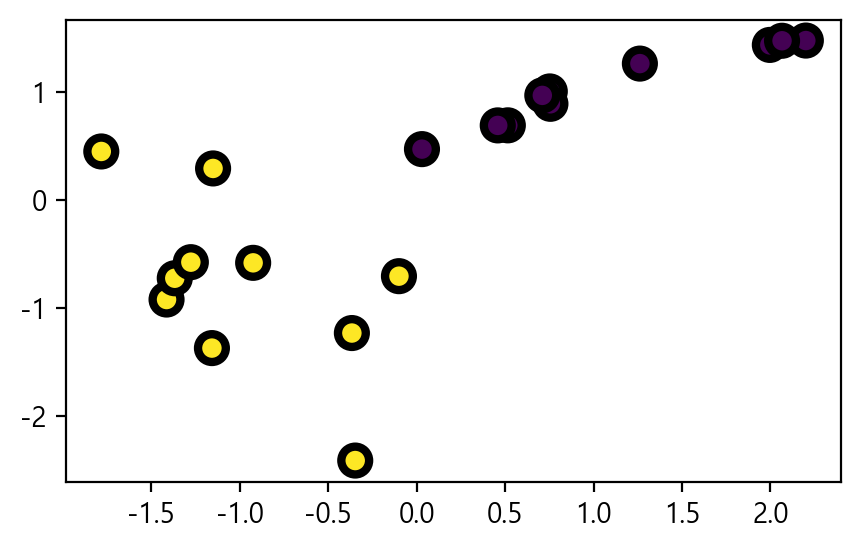

In [13]:
plt.figure(figsize=(5,3))
plt.scatter(x = X[:, 0],
           y = X[:, 1],
           c = y,
           s = 100,
           edgecolors='k',
           lw=3, # line width(선굵기)
           )
plt.show()

In [14]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, # 군의 갯수
              init="k-means++", # 초기 중심점을 서로 멀리 똑똑하게 초기화(random 중심점을 랜덤으로 초기화함)
              n_init=10, # 각 다른 초기값을 10번 실행해보고 가장 좋은 모델 선택(auto 알아서 정해줌)
              max_iter=300) # 각 실행에서 300번 반복(중심 옮기기)
model.fit(X)

KMeans(n_clusters=2, n_init=10)

In [23]:
c0, c1 = model.cluster_centers_ # 최종적으로 모델이 정한 두 중심점
print(c0)
print(c1)

[1.07454973 1.03512672]
[-0.98898305 -0.77918863]


In [21]:
print('modelLabel : ', model.labels_)
pred = model.predict(X)
print("  예 측 값 : ", pred)
print("  실 제 값 : ", y)

modelLabel :  [0 0 1 0 0 0 1 0 0 1 1 0 1 1 1 1 1 0 1 0]
  예 측 값 :  [0 0 1 0 0 0 1 0 0 1 1 0 1 1 1 1 1 0 1 0]
  실 제 값 :  [0 0 1 0 0 0 1 0 0 1 1 0 1 1 1 1 1 0 1 0]


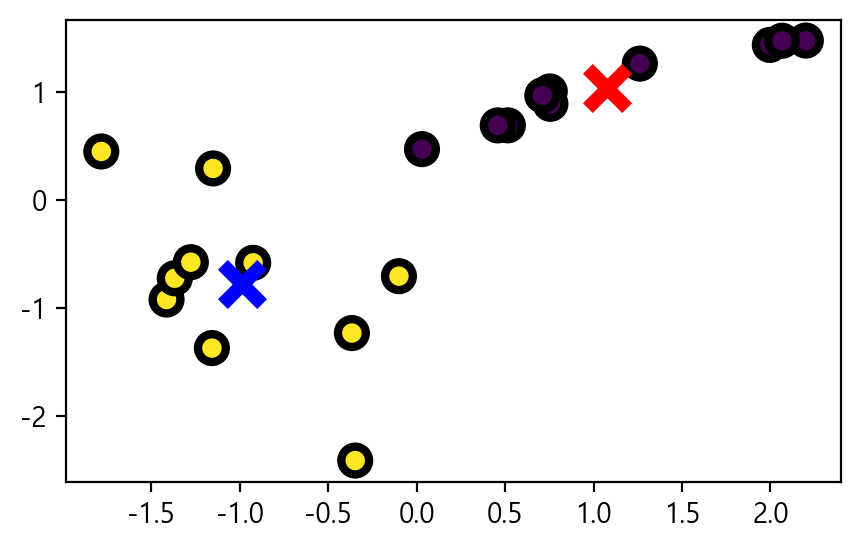

In [27]:
plt.figure(figsize=(5,3))
plt.scatter(x = X[:, 0],
           y = X[:, 1],
           c = pred,
           s = 100,
           edgecolors='k',
           lw=3, # line width(선굵기)
           )
plt.scatter(x = c0[0],
           y = c0[1],
           s = 200,
           marker='x',
           lw = 5,
           c = 'r')
plt.scatter(x = c1[0],
           y = c1[1],
           s = 200,
           marker='x',
           lw = 5,
           c = 'b')
plt.show()

## cf. Normalizer 적용

In [31]:
import pandas as pd
from sklearn.preprocessing import Normalizer
scaler = Normalizer()
Xnor = scaler.fit_transform(X)
np.c_[X, Xnor][:3]

array([[ 1.99650901,  1.43421092,  0.81216571,  0.58342683],
       [ 0.75241859,  1.00360542,  0.59985433,  0.80010923],
       [-1.41424387, -0.92239892, -0.83759272, -0.54629519]])

In [32]:
model = KMeans(n_clusters=2, # 군의 갯수
              init="k-means++", # 초기 중심점을 서로 멀리 똑똑하게 초기화(random 중심점을 랜덤으로 초기화함)
              n_init=10, # 각 다른 초기값을 10번 실행해보고 가장 좋은 모델 선택(auto 알아서 정해줌)
              max_iter=300) # 각 실행에서 300번 반복(중심 옮기기))
model.fit(Xnor)

KMeans(n_clusters=2, n_init=10)

In [33]:
model.labels_ # 모델이 그룹핑한 결과

array([1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1])

In [37]:
d0, d1 = model.cluster_centers_ # 모델이 정한 두개의 중심점
print(d0[0])
print(d0[1])

-0.6630891930414408
-0.5173667120386574


In [ ]:
Xnor[model.labels_ == 0]

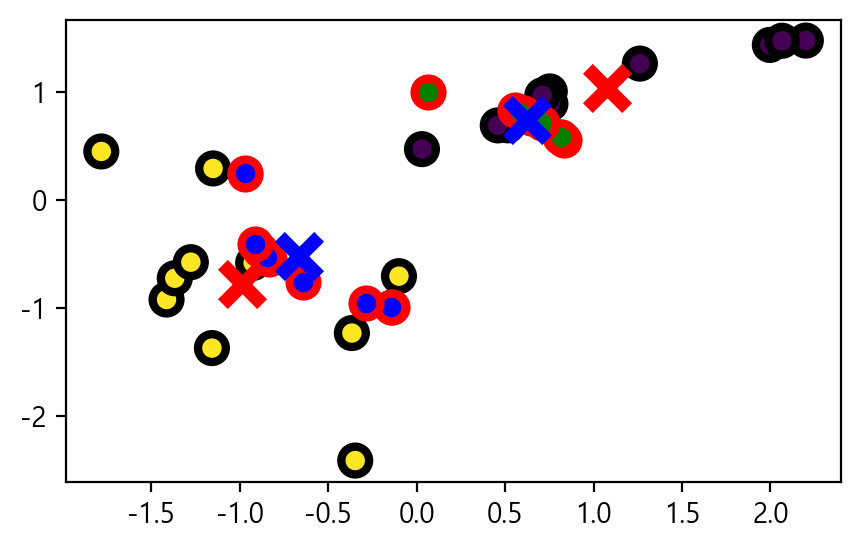

In [43]:
# 노말라이저 안한것
plt.figure(figsize=(5,3))
plt.scatter(x = X[:, 0],
           y = X[:, 1],
           c = pred,
           s = 100,
           edgecolors='k',
           lw=3, # line width(선굵기)
           )
plt.scatter(x = c0[0],
           y = c0[1],
           s = 200,
           marker='x',
           lw = 5,
           c = 'r')
plt.scatter(x = c1[0],
           y = c1[1],
           s = 200,
           marker='x',
           lw = 5,
           c = 'r')

# 노말라이즈 한것
plt.scatter(x = Xnor[model.labels_ == 0, 0],
           y = Xnor[model.labels_ == 0, 1],
           c = 'b',
           s = 100,
           edgecolors='r',
           lw=3, # line width(선굵기)
           )
plt.scatter(x = Xnor[model.labels_ == 1, 0],
           y = Xnor[model.labels_ == 1, 1],
           c = 'g',
           s = 100,
           edgecolors='r',
           lw=3, # line width(선굵기)
           )

plt.scatter(x = d0[0],
           y = d0[1],
           s = 200,
           marker='x',
           lw = 5,
           c = 'b')
plt.scatter(x = d1[0],
           y = d1[1],
           s = 200,
           marker='x',
           lw = 5,
           c = 'b')


plt.show()

In [45]:
from sklearn.cluster import KMeans
import numpy as np

### KMeans의 한계점(p13)
- 군의 특성이 다를 경우
    - 크기
    - 군의 밀도
    - 군이 구형이 아닌 경우(비구형)
- 이상치를 포함할 경우 : 이상치를 조정하거나 삭제한 후 클러스터링

### 군의 크기가 다른 경우

In [51]:
np.random.seed(0)
# 평균 -10, 표준편차 2인 10행 2열 데이터 생성 : group0
group0 = np.random.normal(loc = -10, scale = 2, size = (10, 2))
y = np.full(group0.shape[0], 0)
group0 = np.c_[group0, y]
group0[:2]

array([[-6.47189531, -9.19968558,  0.        ],
       [-8.04252403, -5.5182136 ,  0.        ]])

In [53]:
# 평균 10, 표준편차 2인 10행 2열 데이터 생성 : group1
group1 = np.random.normal(loc = 10, scale = 2, size = (10, 2))
y = np.full(group1.shape[0], 1)
group1 = np.c_[group1, y]
group1[:2]

array([[ 7.90289407,  7.15996413,  1.        ],
       [ 6.58745962, 13.90155079,  1.        ]])

In [54]:
# 평균 0, 표준편차 5인 100행 2열 데이터 생성 : group2
group2 = np.random.normal(loc = 0, scale = 5, size = (100, 2))
y = np.full(group2.shape[0], 2)
group2 = np.c_[group2, y]
group2[:2]

array([[-3.36230224, -1.79776581,  2.        ],
       [-4.06573141, -8.63141301,  2.        ]])

In [57]:
data = np.r_[group0, group1, group2]
data.shape, data[::10]

((120, 3),
 array([[-6.47189531, -9.19968558,  0.        ],
        [ 7.90289407,  7.15996413,  1.        ],
        [-3.36230224, -1.79776581,  2.        ],
        [-5.8257492 ,  4.50413243,  2.        ],
        [ 9.41575349, -6.73879531,  2.        ],
        [ 1.88212766, -5.49700395,  2.        ],
        [-7.45628796,  2.19695851,  2.        ],
        [-2.49016225,  9.64766027,  2.        ],
        [-1.76996956, -6.87475647,  2.        ],
        [-1.84590919, -1.19689589,  2.        ],
        [-4.779725  , -1.72990888,  2.        ],
        [-3.18718513, -1.98635907,  2.        ]]))

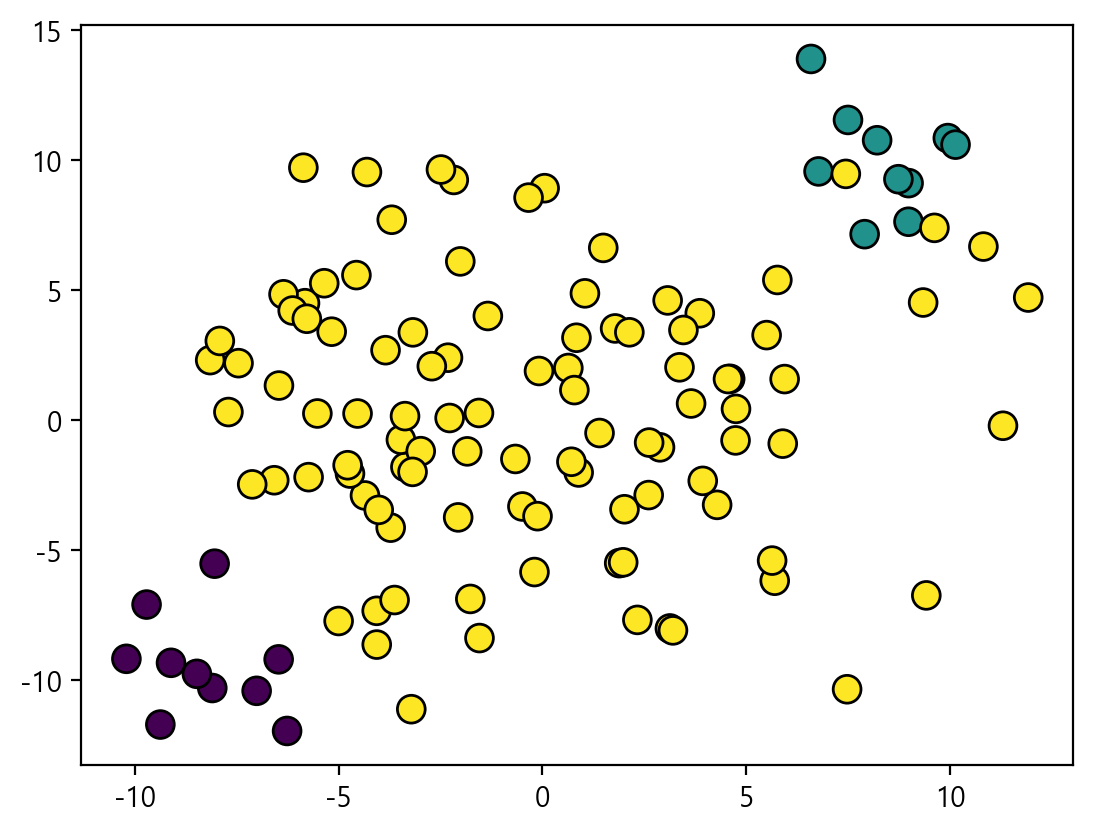

In [61]:
plt.scatter(x=data[:, 0],
           y=data[:, 1],
           c=data[:, 2],
           s=100,
           edgecolors='k')
plt.show()

In [62]:
model = KMeans(n_clusters=3,
              init="k-means++",
              n_init="auto",
              max_iter=300)
model.fit(data[:, :2])

KMeans(n_clusters=3, n_init='auto')

In [63]:
c = model.cluster_centers_ # 군의 중심점
c

array([[-2.48588675, -6.1854847 ],
       [-1.28236299,  2.70036208],
       [ 8.49239286,  7.54361324]])

In [69]:
pred = model.predict(data[:, :2]) # 모델이 분류(군집화)한 클러스터링한 결과
pred = model.labels_
pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 2, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       2, 2, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 2, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 2, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 2, 1, 2, 0, 0, 1, 1, 1, 0, 1, 2, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 2, 0, 0, 1, 1, 0, 1])

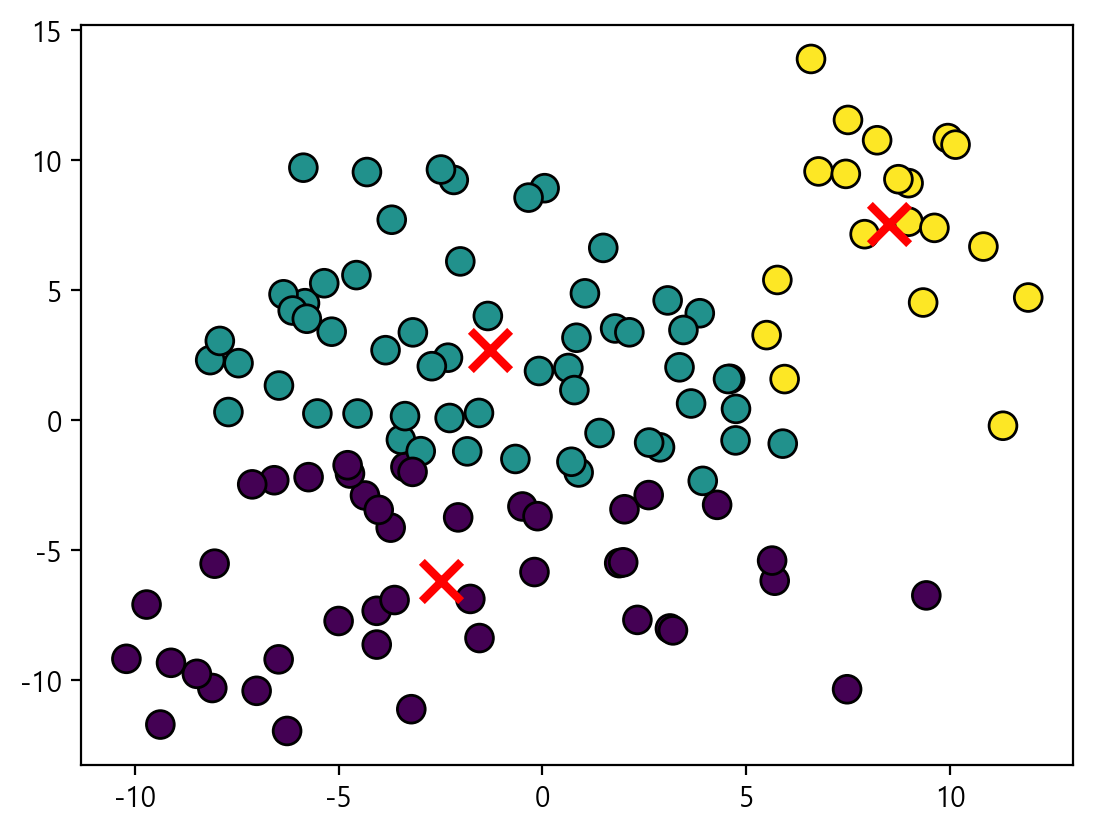

In [71]:
plt.scatter(x=data[:, 0],
           y=data[:, 1],
           c=pred,
           s=100,
           edgecolors='k')
plt.scatter(x=c[:, 0],
           y=c[:, 1],
           c='r',
           marker='x',
           s=200,
           lw=3)
plt.show()

In [72]:
model = KMeans(n_clusters=6,
              init="k-means++",
              n_init=10)
model.fit(data[:, :2])

KMeans(n_clusters=6, n_init=10)

In [73]:
c = model.cluster_centers_ # 중심점
pred = model.labels_ # 모델이 분류(군집화)한 클러스터한 결과
pred

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 3,
       4, 1, 1, 0, 4, 4, 1, 1, 5, 4, 2, 0, 5, 5, 0, 0, 5, 0, 4, 5, 5, 1,
       2, 2, 5, 5, 0, 0, 4, 5, 1, 5, 0, 1, 1, 5, 0, 4, 1, 0, 2, 5, 1, 5,
       1, 4, 4, 1, 5, 0, 5, 3, 0, 0, 4, 5, 1, 1, 3, 3, 4, 1, 5, 1, 4, 0,
       0, 2, 1, 0, 4, 4, 0, 0, 4, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 5, 4, 0,
       1, 1, 3, 0, 3, 4, 4, 0, 3, 1])

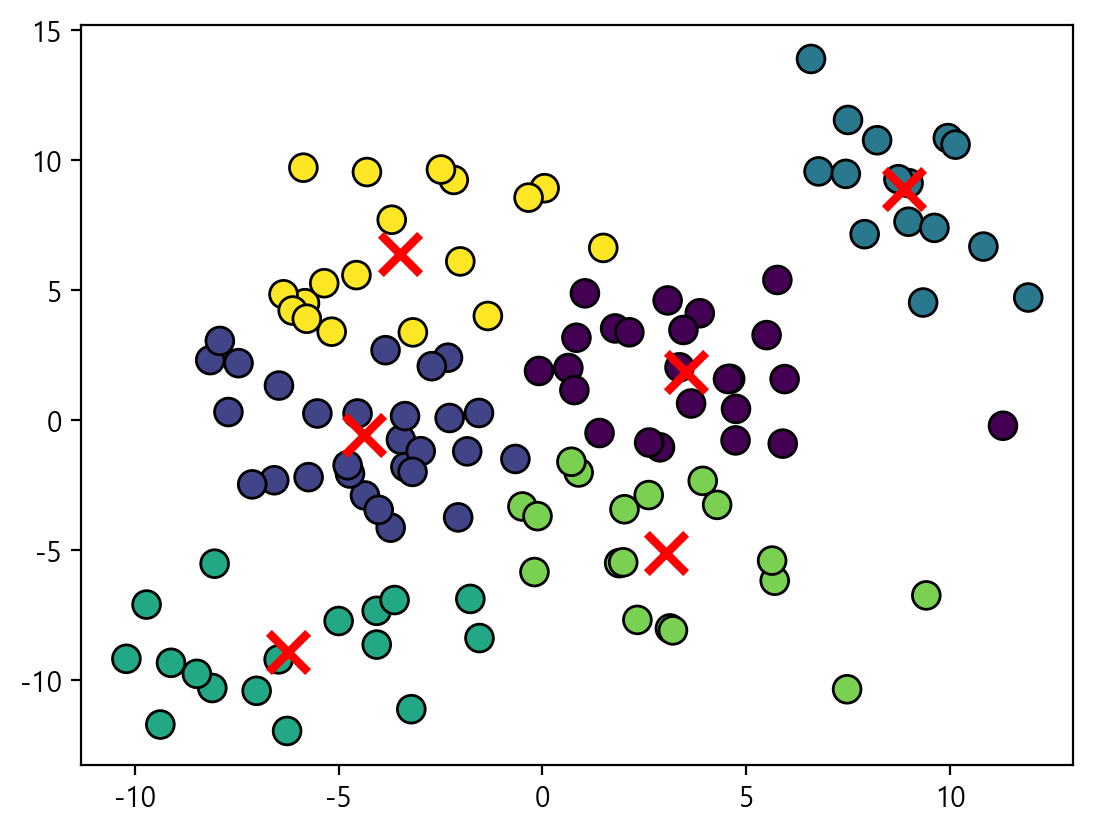

In [74]:
plt.scatter(x=data[:, 0],
           y=data[:, 1],
           c=pred,
           s=100,
           edgecolors='k')
plt.scatter(x=c[:, 0],
           y=c[:, 1],
           c='r',
           marker='x',
           s=200,
           lw=3)
plt.show()

0
1
2
3
4
5


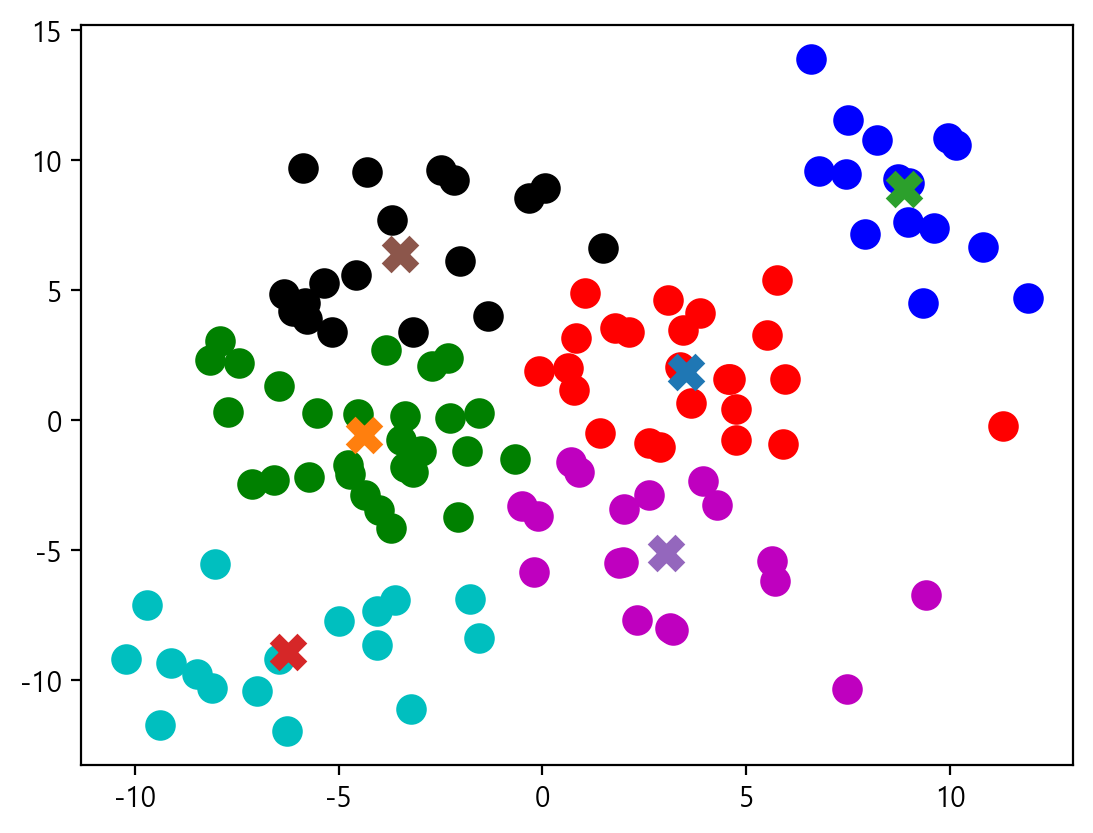

In [79]:
colors = ['r','g','b','c','m','k'] # 012345
# plt.scatter(x=data[pred==0, 0], y=data[pred==0, 1], c=colors[0], s=100)
# plt.scatter(x=data[pred==1, 0], y=data[pred==1, 1], c=colors[1], s=100)
# plt.scatter(x=data[pred==2, 0], y=data[pred==2, 1], c=colors[2], s=100)
# plt.scatter(x=data[pred==3, 0], y=data[pred==3, 1], c=colors[3], s=100)
# plt.scatter(x=data[pred==4, 0], y=data[pred==4, 1], c=colors[4], s=100)
# plt.scatter(x=data[pred==5, 0], y=data[pred==5, 1], c=colors[5], s=100)

for i in range(len(c)):
    plt.scatter(x=data[pred==i, 0], y=data[pred==i, 1], c=colors[i], s=100)
    plt.scatter(x=c[i,0], y=c[i,1], marker='x', s=100, lw=5)
    print(i)

# 3절. Hierachical 클러스터링(계층적 군집)
- 계층적분석(linkage) -> dendrogram -> fcluster를 이용해서 클러스터를 생성(군집화)
    - 군끼리 묶으면서 최종적으로 하나의 군집이 될 때까지 묶는 클러스터링
    - 군집의 수를 미리 정해주지 않음
    - 군집간의 거리 기반으로 클러스터링

In [80]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.sample()

,sepal_length,sepal_width,petal_length,petal_width,species
73,6.1,2.8,4.7,1.2,versicolor


In [82]:
# 계층적 군집 적용을 위해 라벨 인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris['species'] = le.fit_transform(iris.species)

In [84]:
iris[::50]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
50,7.0,3.2,4.7,1.4,1
100,6.3,3.3,6.0,2.5,2


In [85]:
from scipy.cluster.hierarchy import linkage
# method : 클러스터 간 거리(또는 유사도)를 정의하는 방식
# method = "complete" : 두 클러스터 간 점들 사이의 거리 중 가장 큰 값을 군집 간 거리로 사용
# method = "average" : 두 클러스터 간 모든 점쌍의 거리 평균을 군집 간 거리로 사용
# method = "single" : 두 클러스터 간 점들 사이의 거리 중 가장 작은 값을 군집 간 거리로 사용
cluster_model = linkage(iris, method="complete")

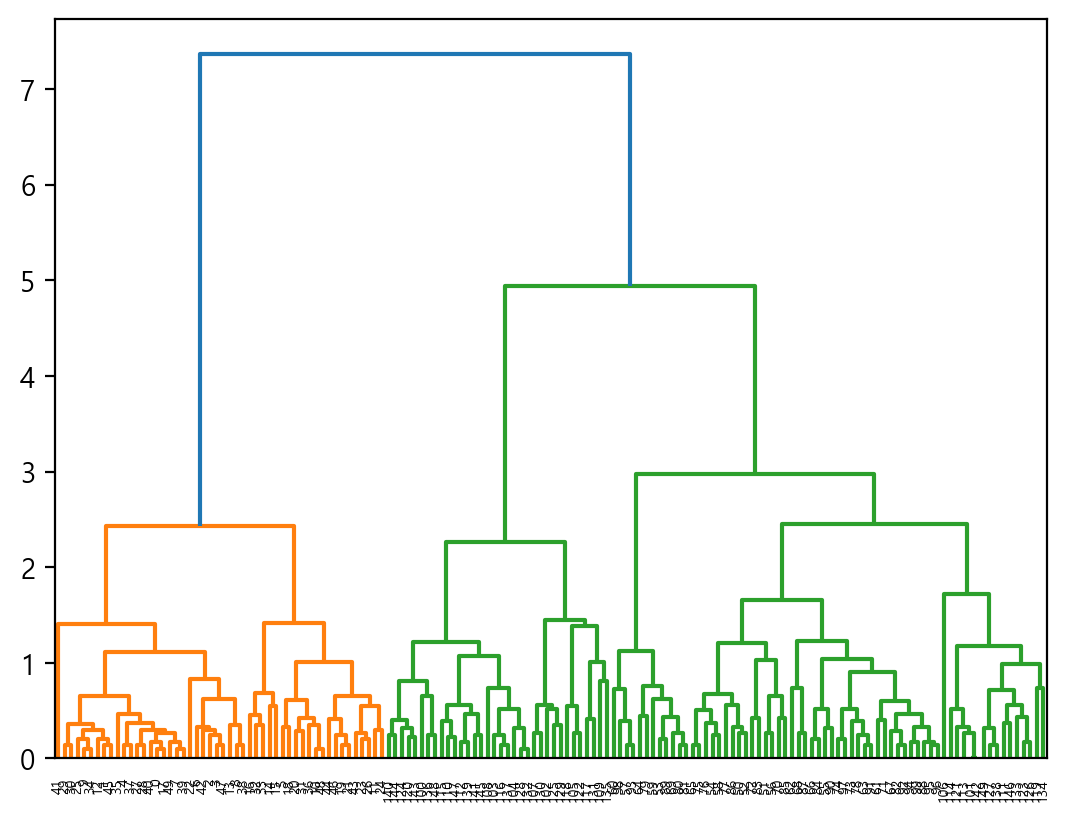

In [87]:
from scipy.cluster.hierarchy import dendrogram
dendrogram(cluster_model, labels=iris.index)
plt.savefig('data/ch02_iris.png', dpi=300, bbox_inches='tight')
plt.show()

In [88]:
from scipy.cluster.hierarchy import fcluster
fcluster(cluster_model, 
         t=4, # dendrogram의 y축의 값 
         criterion="distance") # 군집화 기준
# criterion="distance" 일 때, t값은 dendrogram의 y축 값

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [89]:
fcluster(cluster_model,
        t = 3,
        criterion = "maxclust")
# criterion = "maxclust" 일 때, t값은 클러스터의 갯수(군집화된 그룹 갯수)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [90]:
fcluster(cluster_model, 2, criterion="distance")

array([1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2,
       1, 2, 2, 1, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2,
       2, 1, 2, 1, 2, 1, 6, 6, 6, 5, 6, 6, 6, 5, 6, 5, 5, 6, 6, 6, 5, 6,
       6, 6, 6, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 6, 6, 6, 6, 6, 6,
       6, 5, 6, 6, 6, 5, 6, 6, 6, 6, 5, 6, 3, 7, 4, 3, 3, 4, 7, 4, 3, 4,
       3, 7, 3, 7, 7, 3, 3, 4, 4, 7, 3, 7, 4, 7, 3, 4, 7, 7, 3, 4, 4, 4,
       3, 7, 7, 4, 3, 3, 7, 3, 3, 3, 7, 3, 3, 3, 7, 3, 3, 7], dtype=int32)

# 4절, DBSCAN 클러스터링
- 연결 기반(밀도기반) 군집화 알고리즘(이상치를 자동 감지)
- 단점 : 클러스터의 밀도가 일정하지 않으면 성능이 낮아짐

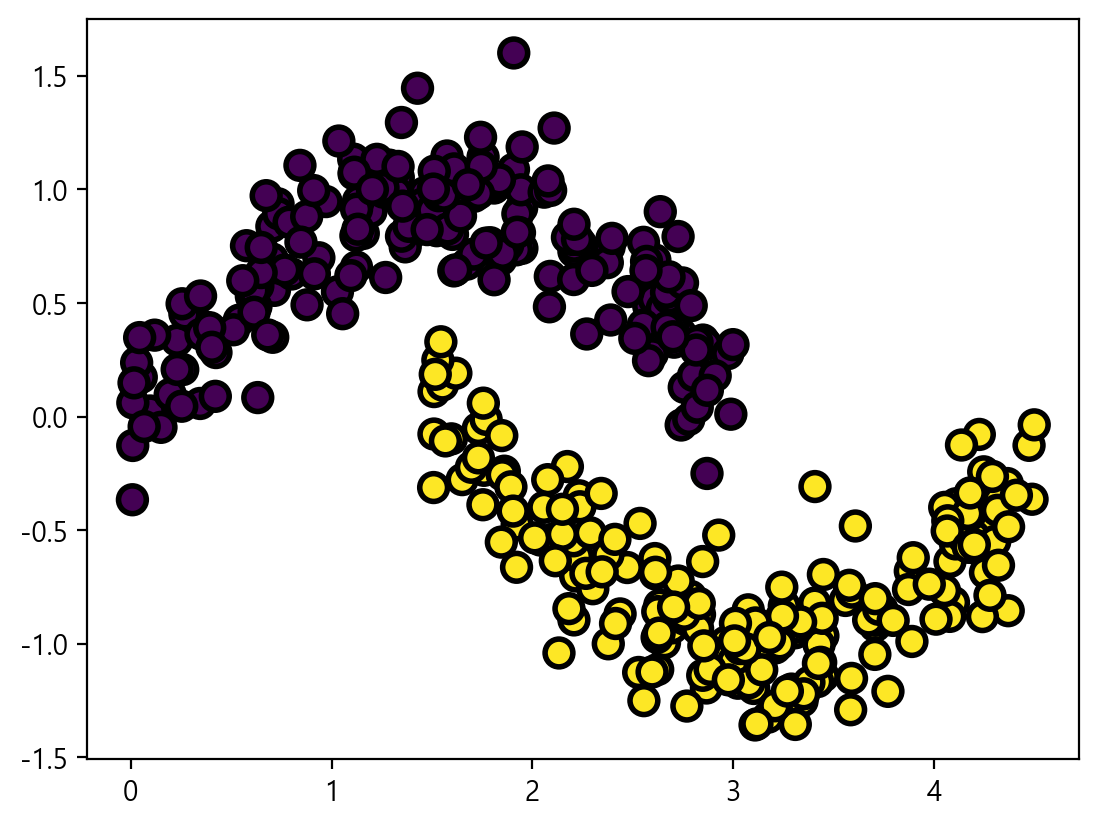

In [105]:
X1 = np.random.rand(200)*3 # 0 <= X1 < 3 의 실수 난수 200개
noise = np.random.normal(0, 0.2, 200)
Y1 = np.sin(X1) + noise
group1 = np.c_[X1, Y1, np.full(X1.shape, 0)]

X2 = X1 + 1.5
Y2 = np.cos(X2) + noise
group2 = np.c_[X2, Y2, np.full(X2.shape, 1)]
data = np.r_[group1, group2]

plt.scatter(data[:, 0], data[:, 1], c=data[:, 2], s=100, edgecolors='k', lw=2)

In [106]:
data[::100]

array([[ 1.90756117,  1.6005479 ,  0.        ],
       [ 0.35018878,  0.36274946,  0.        ],
       [ 3.40756117, -0.3081191 ,  1.        ],
       [ 1.85018878, -0.25609739,  1.        ]])

In [107]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.3, # 반경 0.3 이내에
           min_samples=10, # 최소 10개는 있어야 군집이 만들어지기 시작함
           )
db.fit(data[:, :2])

DBSCAN(eps=0.3, min_samples=10)

In [113]:
labels = db.labels_ # 모델이 군집화한 결과 (-1은 이상치 인식)
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0) # 클러스터 수
n_noise_ = list(labels).count(-1)
print(f'이상치를 제외한 클러스터 수 :{n_clusters_}, 이상치 갯수:{n_noise_}개')

이상치를 제외한 클러스터 수 :2, 이상치 갯수:3개


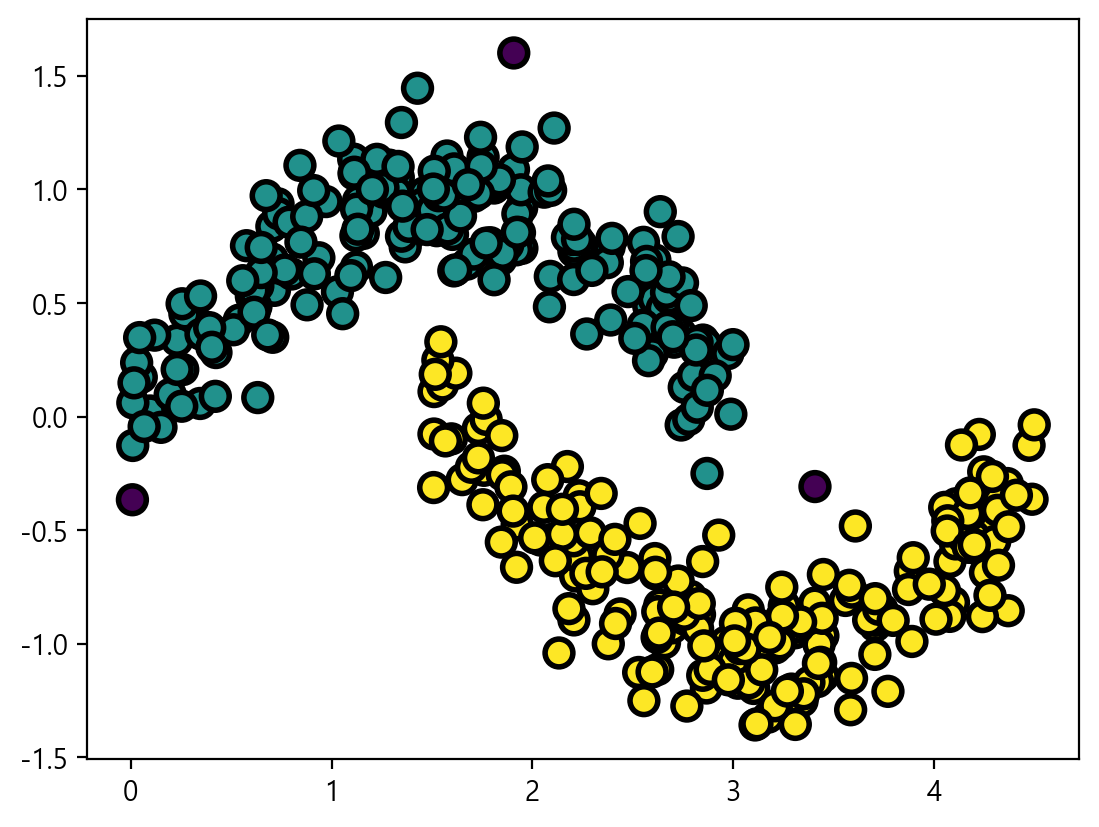

In [115]:
plt.scatter(data[:, 0], data[:, 1], c=labels, s=100, edgecolors='k', lw=2)

# 5절 모형 성능 평가
- score메소드를 통해 예측 모형 평가(분류, 회귀. / 군집에서는 안 씀)
- metrics 모듈의 메소드를 통해 군집 모형 평가

## 5.1 metrics 모듈의 함수 이용
    - 클러스터의 소속과 갯수를 모두 알고 있을 경우 평가

In [145]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [146]:
iris_X = iris.iloc[:, :-1]
iris_y = iris.iloc[:, -1]
iris_X.shape, iris_y.shape

((150, 4), (150,))

In [147]:
iris_model3 = KMeans(n_clusters=3,
                    n_init=10,
                    random_state=1)
iris_model3.fit(iris_X)

KMeans(n_clusters=3, n_init=10, random_state=1)

In [148]:
pred = iris_model3.labels_
# pred = iris_model3.predict(iris_X)

In [149]:
# pred 조정을 위해 : np.choose(arg1, arg2)(배열시퀀스, 배열)
np.choose([3,2,2,3],[0,10,20,30])

array([30, 20, 20, 30])

In [150]:
pred3 = np.choose(iris_model3.labels_,[1,0,2])
pred3 # 조정된 예측값

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1])

In [151]:
# 3개 cluster로 군집화한 자료
print('실제값 :', iris_y[::50])
print('예측값 :', pred3[::50])

실제값 : 0      0
50     1
100    2
Name: species, dtype: int32
예측값 : [0 1 2]


In [152]:
iris_model2 = KMeans(n_clusters=2, n_init=10, random_state=1)
iris_model2.fit(iris_X)

KMeans(n_clusters=2, n_init=10, random_state=1)

In [153]:
pred2 = iris_model2.labels_

In [154]:
# 2개 cluster로 군집화한 자료
iris_y2 = np.array([0]*50 + [1]*100)
print('실제값 : ', iris_y2)
print('예측값 : ', pred2)

실제값 :  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]
예측값 :  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]


In [155]:
# 클러스터가 3개인 경우 평가
from sklearn.metrics import adjusted_rand_score
adjusted_rand_score(labels_true=iris_y, # 실제값
                   labels_pred=pred3) # 클러스터링 예측

0.7302382722834697

In [157]:
# 클러스터가 2개인 경우 평가
adjusted_rand_score(labels_true=iris_y2,
                   labels_pred=pred2)

0.920405050901892

In [158]:
from sklearn.metrics import mutual_info_score # 상호 의존도를 나타내는 지표
# 클러스터가 3개인 경우 평가
mutual_info_score(iris_y, pred3)

0.8255910976103356

In [159]:
# 클러스터가 2개인 경우 평가
mutual_info_score(iris_y2, pred2)

0.5596576064224734

In [160]:
from sklearn.metrics import v_measure_score
v_measure_score(iris_y, pred3)

0.7581756800057784

In [161]:
v_measure_score(iris_y2, pred2) # 2개 그룹으로 군집화하는 것이 좋은 성능이다

0.870385156563164

## 5.2 실루엣 계수
- 클러스터 갯수, 소속을 모두 모르고 있을 경우 평가하는 방법

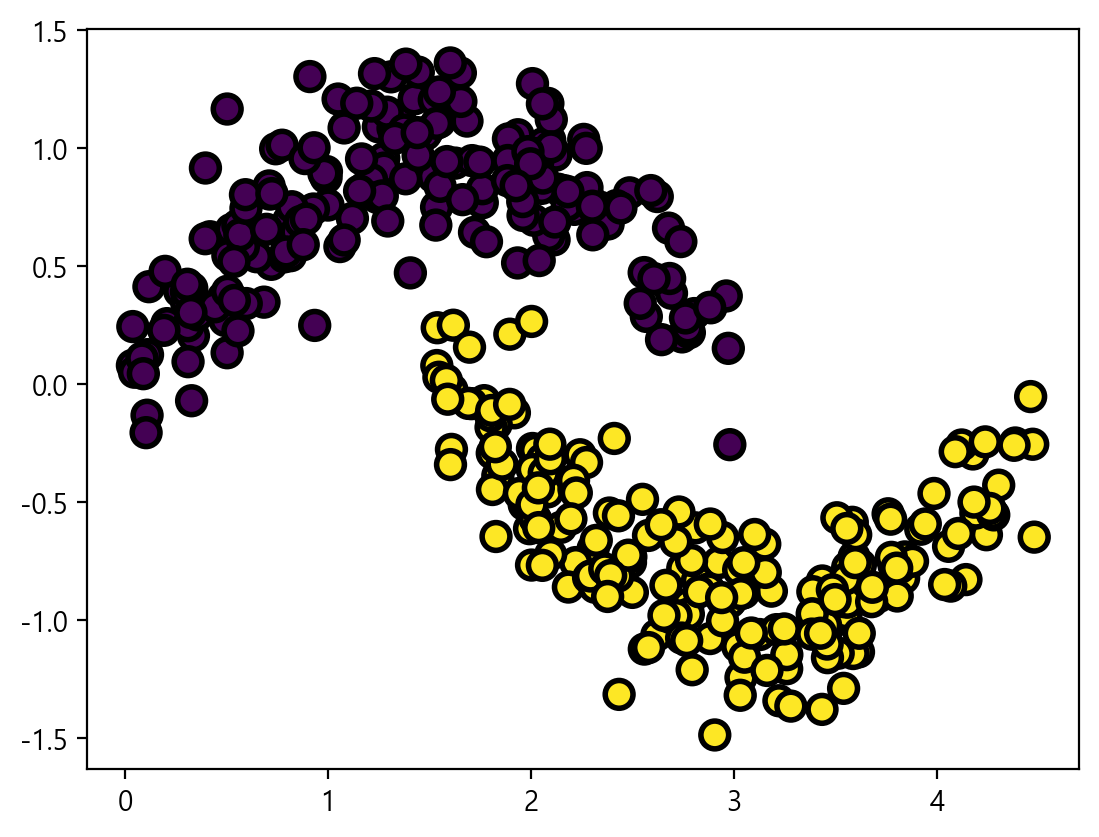

In [162]:
X1 = np.random.rand(200)*3 # 0 <= X1 < 3 의 실수 난수 200개
noise = np.random.normal(0, 0.2, 200)
Y1 = np.sin(X1) + noise
group1 = np.c_[X1, Y1, np.full(X1.shape, 0)]

X2 = X1 + 1.5
Y2 = np.cos(X2) + noise
group2 = np.c_[X2, Y2, np.full(X2.shape, 1)]
data = np.r_[group1, group2]

plt.scatter(data[:, 0], data[:, 1], c=data[:, 2], s=100, edgecolors='k', lw=2)

In [165]:
from sklearn.metrics import silhouette_score
range_n_clusters = [2,3,4,5,6,7,8,9,10]
for n_clusters in range_n_clusters:
    model = KMeans(n_clusters=n_clusters,
                  n_init=10,
                  random_state=2)
    model.fit(data[:, :-1])
    score = silhouette_score(X=data[:, :-1],
                            labels=model.labels_)
    print("클러스터(그룹) 수 : {} 일 때, 실루엣 계수 : {}".format(n_clusters, score))
# 실루엣 계수가 가장 높은 6개로 클러스터링 할 예정

클러스터(그룹) 수 : 2 일 때, 실루엣 계수 : 0.539405067506624
클러스터(그룹) 수 : 3 일 때, 실루엣 계수 : 0.46180138590728026
클러스터(그룹) 수 : 4 일 때, 실루엣 계수 : 0.47956005475680596
클러스터(그룹) 수 : 5 일 때, 실루엣 계수 : 0.46927471771588813
클러스터(그룹) 수 : 6 일 때, 실루엣 계수 : 0.47936396761939676
클러스터(그룹) 수 : 7 일 때, 실루엣 계수 : 0.4597506620719624
클러스터(그룹) 수 : 8 일 때, 실루엣 계수 : 0.4677767055313213
클러스터(그룹) 수 : 9 일 때, 실루엣 계수 : 0.4550584627884071
클러스터(그룹) 수 : 10 일 때, 실루엣 계수 : 0.45707700378624766


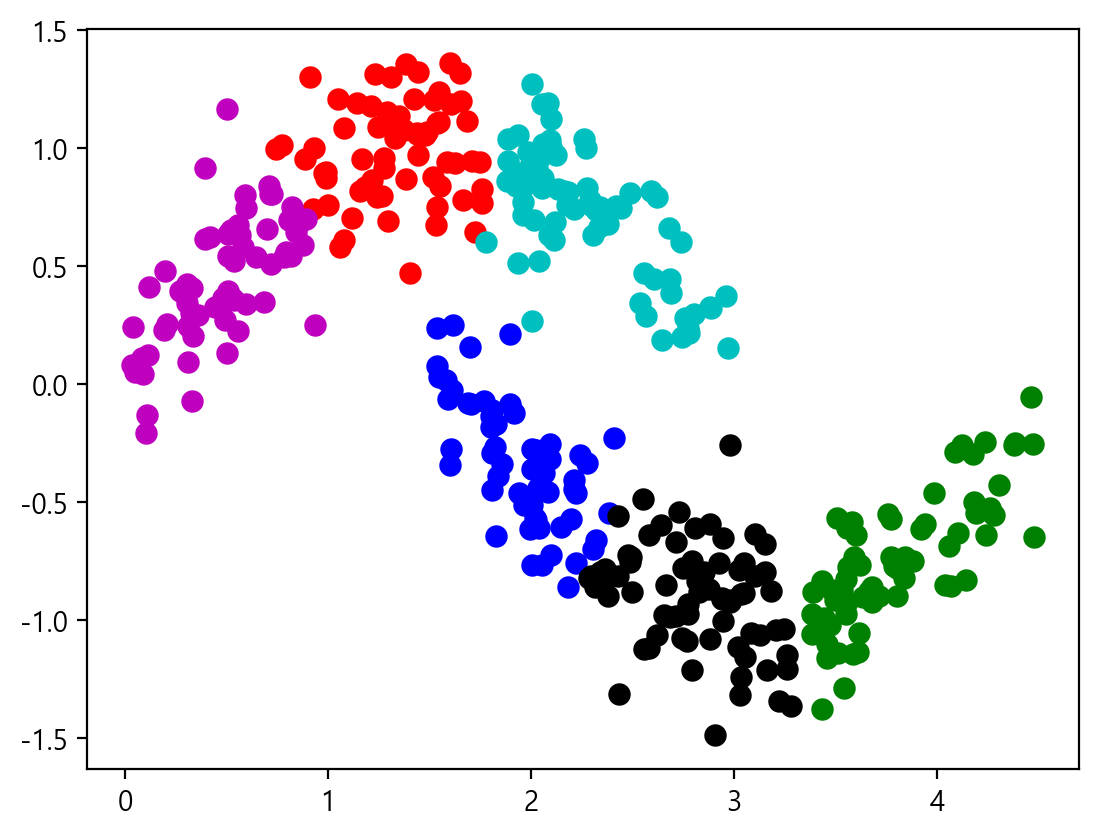

In [173]:
model = KMeans(n_clusters=6, n_init=10, init="k-means++")
model.fit(data[:, :-1])
centers = model.cluster_centers_
colors = ['r','g','b','c','m','k']

# plt.scatter(data[model.labels_==0, 0],
#             data[model.labels_==0, 1],
#             c = colors[0])
for i in range(len(c)):
    plt.scatter(x=data[model.labels_==i, 0], y=data[model.labels_==i, 1], c=colors[i], s=50)